<h1 style='color:red'>Function Transformer</h1>

<h2 style="color:blue">QQ PLOTS</h2>

<div style='display: flex; flex-direction: row; gap: 10px;'>
    <img style="width:600px" src='images/QQ_plot1.png'>
    <img style="width:500px" src='images/QQ_plot2.jpg'>
</div>

<h2 style="color:blue">Log Transform</h2>

In [1]:
# we take log of all the values of that column
# log transform tansforms *right skewed* data to *near-normal distribution*, as log of larger values are is comparatively small.
# log converts *additive scale* to *multiplicative scale*.
# ⚠️ Requires positive values, can't apply it on -ve values.

<h2 style="color:blue">Other Transform</h2>

In [2]:
# Reciprocal Transform : (1/x)
# → Strongly compresses large values and expands small values
# → Very effective for highly right-skewed data, Reduces the influence of extreme outliers
# ⚠️ Only works for non-zero, positive values

# Square Transform : (x^2)
# → Expands larger values much more than smaller ones
# → Useful for correcting left-skewed (negatively skewed) distributions, Increases separation between large values
# ⚠️ Can amplify outliers if data is already right-skewed

# Square Root Transform : sqrt(x)
# → Mild transformation compared to log or reciprocal
# → Reduces moderate right skewness, Stabilizes variance in count-based data, Commonly used when data contains zeros

<h3 style="color:blue">How to find if data is normal or not</h3>

In [3]:
# 1).   sns.kdeplot()      # pdf of data
# 2).   pd.skew() 
# 3).   QQ plots

In [4]:
import pandas as pd 
import numpy as np 

import scipy.stats as stats     # for Plotting QQ plots

import matplotlib.pyplot as pyplot 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [8]:
df.sample(5)

,Survived,Age,Fare
8,1,27.000000,11.1333
666,0,25.000000,13.0000
64,0,29.699118,27.7208
189,0,36.000000,7.8958
136,1,19.000000,26.2833


<h3 style="color:blue">Observing Columns via QQ plot</h3>

In [9]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df['Survived'], test_size=0.25, random_state=0)

X_train.shape, X_test.shape

((668, 2), (223, 2))

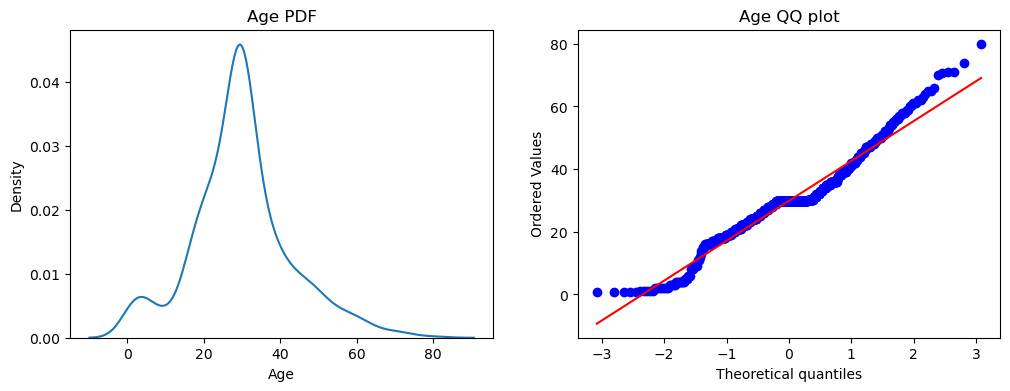

In [10]:
pyplot.figure(figsize=(12, 4))
pyplot.subplot(121)
sns.kdeplot(x=X_train['Age'])
pyplot.title("Age PDF")

pyplot.subplot(122)
stats.probplot(x=X_train['Age'], dist='norm', plot=pyplot)           # plot = pyplot,  Specifies where to draw the QQ plot
# dist = 'norm', 'expon' , 'uniform' ,   Specifies the theoretical distribution
pyplot.title("Age QQ plot")

pyplot.show()

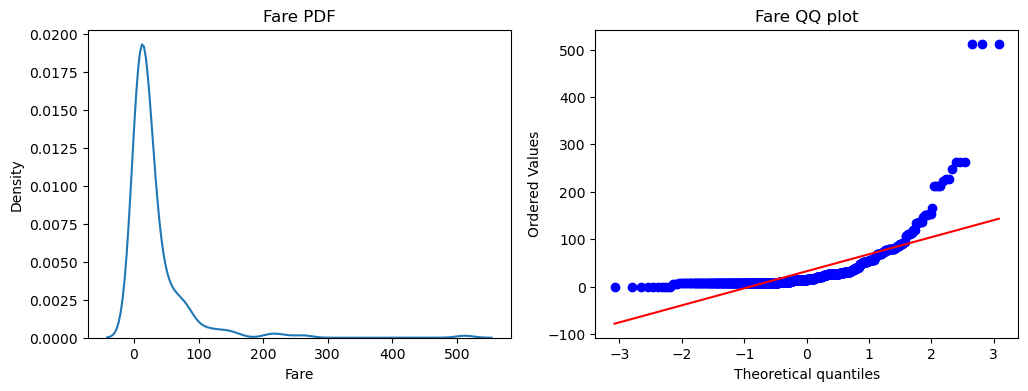

In [11]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(121)
sns.kdeplot(x=X_train['Fare'])
pyplot.title("Fare PDF")

pyplot.subplot(122)
stats.probplot(x=X_train['Fare'], dist='norm', plot=pyplot)
pyplot.title("Fare QQ plot")

pyplot.show()

In [12]:
df['Fare'].skew()    #  Skewness can take any real value

np.float64(4.787316519674893)

<h3 style="color:blue">Training Model</h3>

In [13]:
lr = LogisticRegression() 
dt = DecisionTreeClassifier()

In [14]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

print("Accuracy LR : ", accuracy_score(y_test, y_pred_lr))
print("Accuracy DT : ", accuracy_score(y_test, y_pred_dt))
# Decision Tree Accuracy doesn;t depends on the distribution of data, it will give same accuracy for normal dist, left-skewed, right-skewed.

Accuracy LR :  0.6860986547085202
Accuracy DT :  0.672645739910314


<h3 style="color:blue">Applying Log Function Transformation</h3>

In [15]:
# Calling Function Transformer
tnf = FunctionTransformer(func=np.log1p)        #  log1p(x) = log(1 + x) when data contains zeros, it can give a definite value

In [16]:
# Applying log Transformer to X_train and X_test
X_train_tnf = tnf.fit_transform(X_train)
X_test_tnf = tnf.fit_transform(X_test)

In [17]:
lr = LogisticRegression() 
dt = DecisionTreeClassifier() 

lr.fit(X_train_tnf, y_train)
dt.fit(X_train_tnf, y_train)

y_pred_lr = lr.predict(X_test_tnf)
y_pred_dt = dt.predict(X_test_tnf)

print("Accuracy LR :", accuracy_score(y_pred_lr, y_test))
print("Accuracy DT :", accuracy_score(y_pred_dt, y_test))

Accuracy LR : 0.7130044843049327
Accuracy DT : 0.6681614349775785


In [18]:
# Cross_val_score
X_tnf = tnf.fit_transform(df.iloc[:, 1:])

lr = LogisticRegression() 
dt = DecisionTreeClassifier() 

print("LR :", np.mean(cross_val_score(lr, X_tnf, df['Survived'], scoring='accuracy', cv=10)))
print("DT :", np.mean(cross_val_score(dt, X_tnf, df['Survived'], scoring='accuracy', cv=10)))

LR : 0.678027465667915
DT : 0.6588639200998752


<h2 style="color:blue">Analysing via QQ plots</h2>

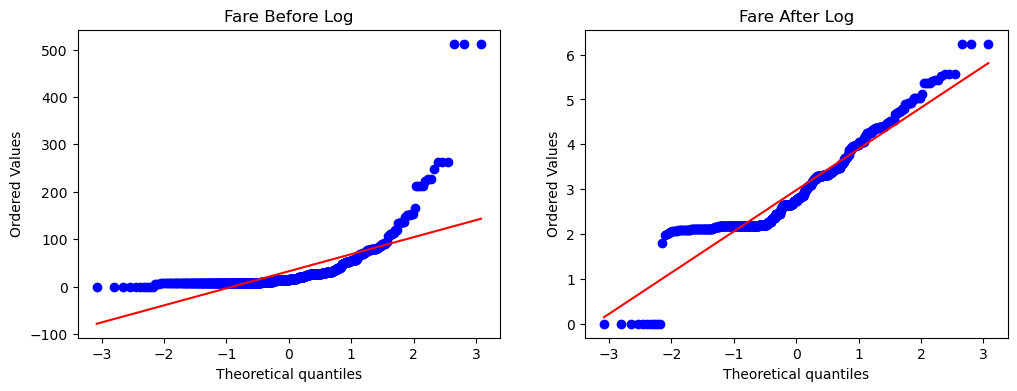

In [19]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=pyplot)
pyplot.title("Fare Before Log")

pyplot.subplot(122)
stats.probplot(X_train_tnf['Fare'], dist='norm', plot=pyplot)
pyplot.title("Fare After Log")

pyplot.show()
# as we can observe that initially Fare PDF was positively skewed, so after applying Log Transform it has near-normal distribution.

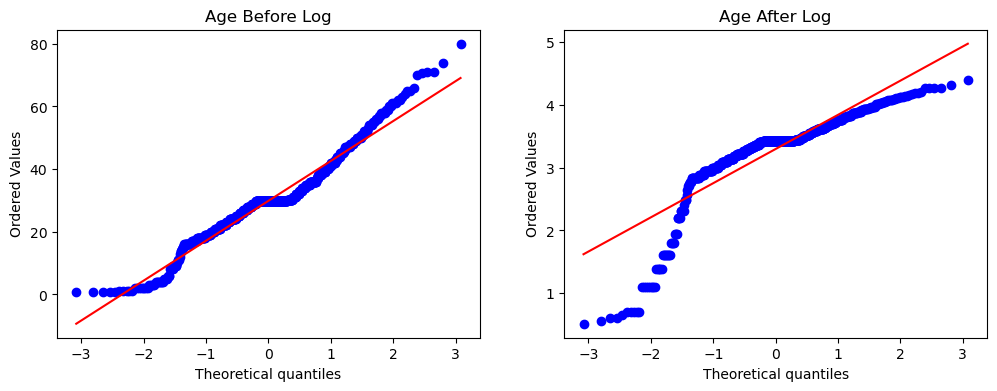

In [20]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=pyplot)
pyplot.title("Age Before Log")

pyplot.subplot(122)
stats.probplot(X_train_tnf['Age'], dist='norm', plot=pyplot)
pyplot.title("Age After Log")

pyplot.show()
# as the Age distribution already has normal distribution initially, so after applying Log Transform it becomes left-skewed distribution.

In [21]:
# Appling Log Transform on Fare column only
tnf2 = ColumnTransformer(
                        transformers=[('log',FunctionTransformer(func = np.log1p), ['Fare'])], 
                        remainder='passthrough'
                        )

In [22]:
X_train_tnf2 = tnf2.fit_transform(X_train)
X_test_tnf2 = tnf2.fit_transform(X_test)

lr = LogisticRegression() 
dt = DecisionTreeClassifier()

lr.fit(X_train_tnf2, y_train)
dt.fit(X_train_tnf2, y_train)

y_pred_lr = lr.predict(X_test_tnf2)
y_pred_dt = dt.predict(X_test_tnf2)

print("Accuracy LR :", accuracy_score(y_pred_lr, y_test))
print("Accuracy DT :", accuracy_score(y_pred_dt, y_test))

Accuracy LR : 0.6905829596412556
Accuracy DT : 0.6681614349775785


In [23]:
# cross_val_score
X_tnf2 = tnf2.fit_transform(df.iloc[:, 1:])

lr = LogisticRegression() 
dt = DecisionTreeClassifier() 

print("LR :", np.mean(cross_val_score(lr, X_tnf2, df['Survived'], scoring='accuracy', cv=10)))
print("DT :", np.mean(cross_val_score(dt, X_tnf2, df['Survived'], scoring='accuracy', cv=10)))

LR : 0.6712609238451936
DT : 0.6610736579275904


# Other Transformers

In [24]:
def apply_transform(transform): 
    X = df.iloc[:, 1:]
    Y = df.iloc[:, 0] 

    tnf = ColumnTransformer(transformers=[('transform', FunctionTransformer(func=transform), ['Fare'])], remainder='passthrough')

    X_tnf = tnf.fit_transform(X)

    lr = LogisticRegression()
    print("Accuracy :", np.mean(cross_val_score(lr, X_tnf, Y, scoring='accuracy', cv=10)))

    # Drawing QQ Plots before and after applying "Function Transformation
    pyplot.figure(figsize=(12,4))
    pyplot.subplot(121)
    stats.probplot(X['Fare'], dist='norm', plot=pyplot)
    pyplot.title("QQ plot before Function Transformation")
    
    pyplot.subplot(122)
    stats.probplot(X_tnf[:, 0], dist='norm', plot=pyplot)    # X_tnf -> pandas series
    pyplot.title("QQ plot After Function Transformation")
    pyplot.show()

Accuracy : 0.6431335830212235


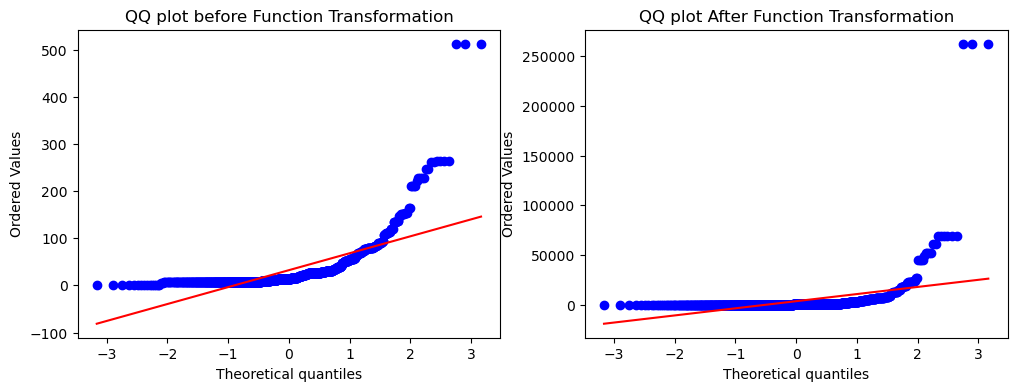

In [25]:
apply_transform(lambda x: x**2)            # for square transformer
# lambda is just a short way to create a function in one line.    
# lambda arguments: expression,   multiple arguments can be there, but only one expression can be passed after colon(:).

# x**2 is an expression, not a function
# Python cannot pass expressions directly,  So we wrap it inside a function using lambda

Accuracy : 0.61729088639201


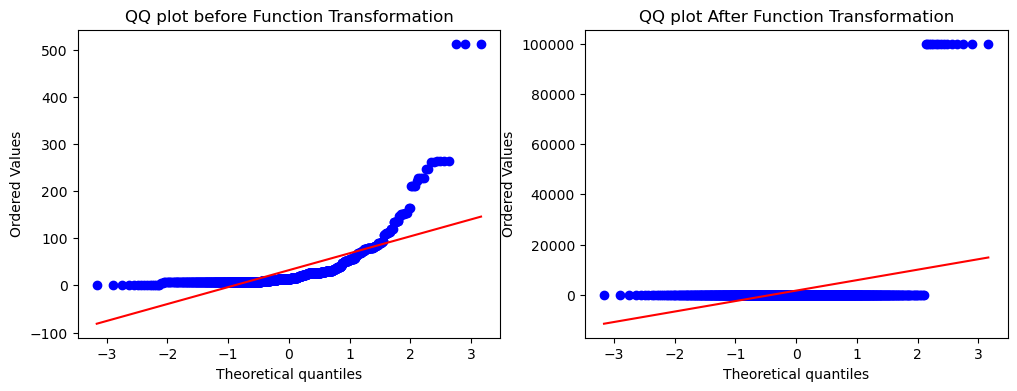

In [26]:
apply_transform(lambda x: 1/(x+0.00001))         # for reciprocal (1/x)

Accuracy : 0.6195131086142323


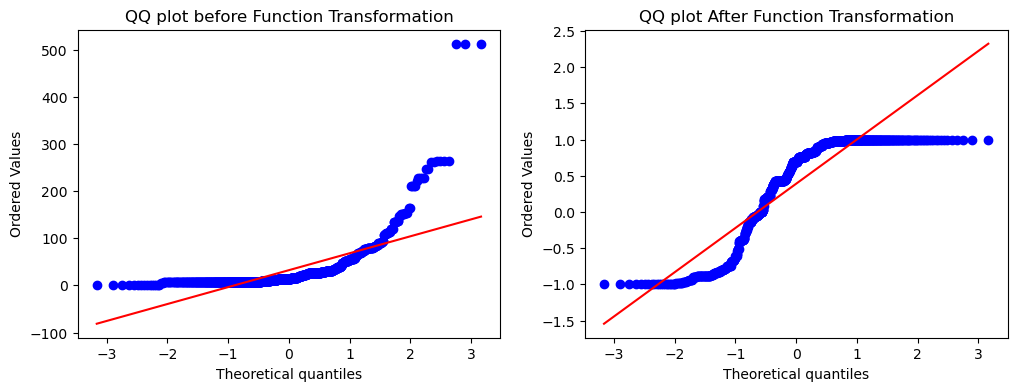

In [27]:
apply_transform(np.sin)         # for arbitary function sinX,    np.sin is already a callable function

Accuracy : 0.616167290886392


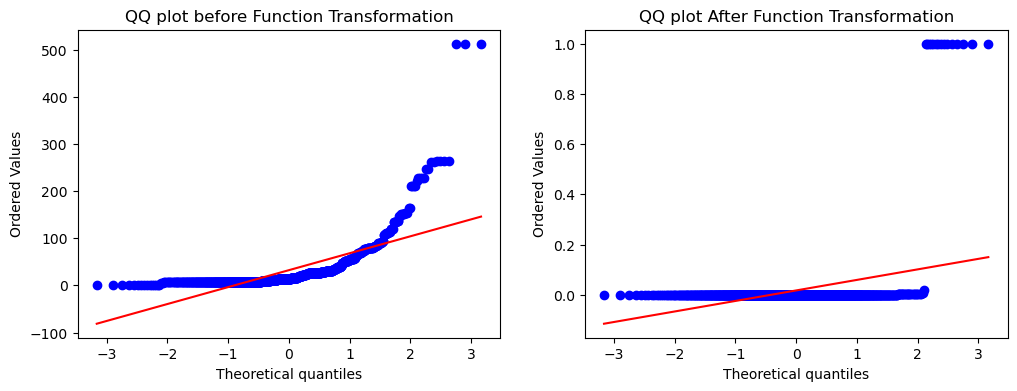

In [29]:
apply_transform(lambda x: np.e**(-x))     # e^(-x)